In [1]:
import numpy as np
import pandas as pd
import os
from glob import glob
from functools import reduce
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import linregress
import statsmodels.api as smcd
import statsmodels.formula.api as smf
from statsmodels.genmod.families import Gaussian
from collections import Counter
from tqdm import tqdm
import statsmodels.api as sm
import scipy.stats
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42 
plt.rcParams['font.family'] = 'Arial'
from scipy.stats import zscore
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests
from scipy.stats import zscore
from scipy.optimize import curve_fit

In [2]:
metafile = pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/PEC_donor_LIMS_082625.csv', header=0, sep=',')
qcfile = pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/metadata_DNA_QC.tsv.gz',index_col = [0],compression='gzip', header=0, sep='\t')
rnaqc=pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/metadata_RNA_QC.tsv.gz',sep='\t',index_col=0)
glob_methy = pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/Individual_globalMethylation_autosome_cov3to50_all.tsv.gz',index_col = [0],compression='gzip', header=0, sep='\t')
local_methly_info = pd.read_csv('/cndd/hex002/PsychEncode/methylation/local_methylation_backgroud/Backgroud_methylation.csv',index_col = [0,1,2], header=[0,1,2,3,4,5])

## PCA Plot

In [3]:
genebody_mCG=pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/regionMethylation/intragenic_masked_mCG_all.tsv.gz',sep='\t',index_col=0)
genebody_mCG=genebody_mCG.loc[qcfile[(qcfile['DNA_passQC']=='True')].index]
genebody_mCH=pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/regionMethylation/intragenic_masked_mCH_all.tsv.gz',sep='\t',index_col=0)
genebody_mCH=genebody_mCH.loc[qcfile[(qcfile['DNA_passQC']=='True')].index]
rnaexp=pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/RNA_expression_log2CPM+1.tsv.gz',sep='\t',index_col=0)
rnaexp=rnaexp[rnaqc[rnaqc['RNA_passQC']].index]

In [4]:
gene_meta=pd.read_csv('/cndd2/jchien/iGenome/gencodev37/gencode.v37.annotation.intragenic_filter.bed.gz',
                      names=['chr','start','end','gene_id','starnd','tmp','gene_name','fn'],
                      index_col='gene_id', sep='\t')
gene_meta['len']=gene_meta['end']-gene_meta['start']    

In [5]:
sex_palette={'Female':'#F16090','Male':'#61A3D7'}
celltype_palette={'GLU':'#4FAF48','GABA':'#397FBA'}
period_order=['Infancy', 'Early_Childhood', 'Late_Childhood', 'Adolescence', 'Adulthood','Late_Adulthood']

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

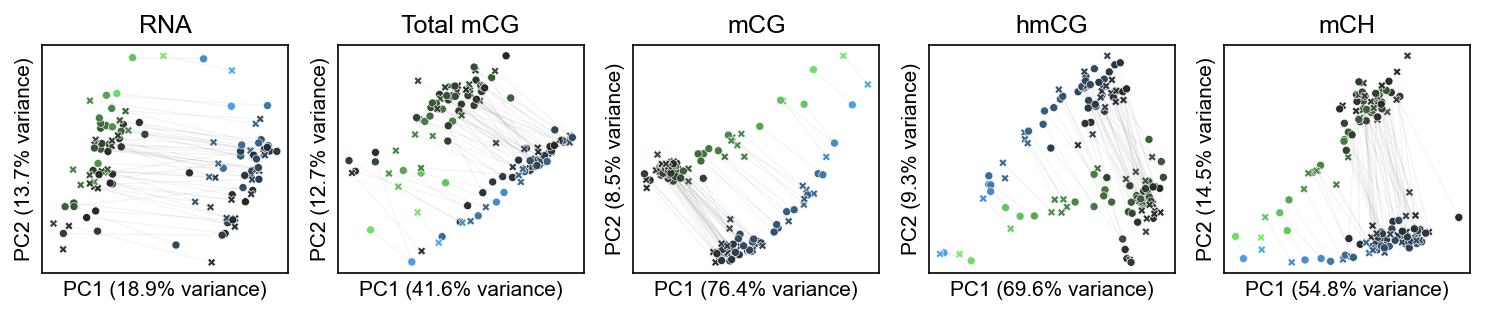

In [7]:
glu_palette = sns.dark_palette('#75eb6c', as_cmap=True, reverse=True)
gaba_palette = sns.dark_palette('#4ea7f2', as_cmap=True, reverse=True)

fig, axs = plt.subplots(1, 5, figsize=(10, 2.2), dpi=150)

for i in range(5):
    if i == 0:
        df = rnaexp.copy()
        df = df.loc[list(set(df.index).intersection(set(gene_meta[(gene_meta['fn'].isin(['protein_coding'])) & (gene_meta['len'] > 1000) & ~(gene_meta['chr'].str.contains('[XYM]'))].index)))].dropna().T
        df_meta = df.join(rnaqc[['age', 'celltype', 'sex']])[['age', 'celltype', 'sex']]
        title = 'RNA'
    elif i == 1:
        df = genebody_mCG[genebody_mCG.index.str.contains(f'_BS')].T
        df = df.loc[list(set(df.index).intersection(set(gene_meta[(gene_meta['fn'].isin(['protein_coding'])) & (gene_meta['len'] > 1000) & ~(gene_meta['chr'].str.contains('[XYM]'))].index)))].dropna().T
        df_meta = df.join(qcfile[['age', 'celltype', 'sex', 'DNA_passQC']])[['age', 'celltype', 'sex', 'DNA_passQC']]
        title = 'Total mCG'
    elif i == 2:
        df = genebody_mCG[genebody_mCG.index.str.contains(f'_OXBS')].T
        df = df.loc[list(set(df.index).intersection(set(gene_meta[(gene_meta['fn'].isin(['protein_coding'])) & (gene_meta['len'] > 1000) & ~(gene_meta['chr'].str.contains('[XYM]'))].index)))].dropna().T
        df_meta = df.join(qcfile[['age', 'celltype', 'sex', 'DNA_passQC']])[['age', 'celltype', 'sex', 'DNA_passQC']]
        title = 'mCG'
    elif i == 3:
        bs=genebody_mCG[genebody_mCG.index.str.contains(f'_BS')].T
        ox=genebody_mCG[genebody_mCG.index.str.contains(f'_OXBS')].T
        bs.columns = bs.columns.str.replace('_BS','')
        ox.columns = ox.columns.str.replace('_OXBS','')
        df = bs-ox
        df[df<0]=0
        df.columns = df.columns+'_BS'
        df = df.loc[list(set(df.index).intersection(set(gene_meta[(gene_meta['fn'].isin(['protein_coding'])) & (gene_meta['len'] > 1000) & ~(gene_meta['chr'].str.contains('[XYM]'))].index)))].dropna().T
        df_meta = df.join(qcfile[['age', 'celltype', 'sex', 'DNA_passQC']])[['age', 'celltype', 'sex', 'DNA_passQC']]
        title = 'hmCG'
    else:
        df = genebody_mCH[genebody_mCH.index.str.contains(f'_OXBS')].T
        df = df.loc[list(set(df.index).intersection(set(gene_meta[(gene_meta['fn'].isin(['protein_coding'])) & (gene_meta['len'] > 1000) & ~(gene_meta['chr'].str.contains('[XYM]'))].index)))].dropna().T
        df_meta = df.join(qcfile[['age', 'celltype', 'sex', 'DNA_passQC']])[['age', 'celltype', 'sex', 'DNA_passQC']]
        title = 'mCH'
    
    # Standardize the data
    scaler = StandardScaler()
    df = scaler.fit_transform(df)
    pca = PCA(n_components=2)
    projected = pca.fit_transform(df)

    df_meta['PC1'] = projected[:, 0]
    df_meta['PC2'] = projected[:, 1]
    df_meta['donor'] = df_meta.index.str.split('_G').str[0]
    df_meta['logage'] = np.log10(df_meta['age'])
    
    ax = axs[i]
    for celltype, palette in [('GLU', glu_palette), ('GABA', gaba_palette)]:
        if i == 0:
            points = sns.scatterplot(
                data=df_meta[df_meta['celltype'] == celltype],
                x='PC1', y='PC2', 
                hue='logage', style='sex', markers={'Male': 'o', 'Female': 'X'},
                palette=palette, s=15, edgecolor='w', linewidth=0.3, ax=ax
            )
        else:
            sns.scatterplot(
                data=df_meta[(df_meta['celltype'] == celltype) & (df_meta['DNA_passQC'] == 'True')],
                x='PC1', y='PC2', 
                hue='logage', style='sex', markers={'Male': 'o', 'Female': 'X'},
                palette=palette, s=15, edgecolor='w', linewidth=0.3, ax=ax
            )
            sns.scatterplot(
                data=df_meta[(df_meta['celltype'] == celltype) & (df_meta['DNA_passQC'] == 'SCZ')],
                x='PC1', y='PC2', 
                style='sex', markers={'Male': 'o', 'Female': 'X'},
                s=15, edgecolor=celltype_palette[celltype], linewidth=.5, ax=ax, facecolor='none'
            )
    
    # Add lines linking celltypes from the same donors
    for donor, group in df_meta.groupby('donor'):
        if len(group) > 1:
            ax.plot(group['PC1'], group['PC2'], color='gray', linewidth=0.5, alpha=0.1)
    
    ax.set_xlabel(f'PC1 ({100 * pca.explained_variance_ratio_[0]:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({100 * pca.explained_variance_ratio_[1]:.1f}% variance)')
    ax.legend().remove()
    ax.set_xticks([]) 
    ax.set_yticks([]) 
    ax.set_title(title)

plt.tight_layout()

## Read 10kb files

In [8]:
datadir = '/cndd2/jchien/project/Dracheva_Development/regionMethylation/10kb_bin/individual/'

In [9]:
binc = pd.read_csv('/cndd/hex002/PsychEncode/methylation/local_methylation_backgroud/10kb_methylation_CGCH_chr1_22X.tsv.gz',index_col=[0,1,2],header=[0, 1, 2, 3, 4, 5],sep = '\t')
binc.head()

subject                 4414                                          \
sex                   Female                                           
age                      0.1                                           
celltype                 GLU                                    GABA   
mctype                    BS                OXBS                  BS   
ctxt                     mCG       mCH       mCG       mCH       mCG   
chr  start  end                                                        
chr1 790000 800000  0.841026  0.013443  0.722380  0.012306  0.914980   
     800000 810000  0.895543  0.015591  0.702381  0.015837  0.861912   
     810000 820000  0.734472  0.014519  0.536232  0.024163  0.698551   
     820000 830000  0.529978  0.011805  0.328494  0.011011  0.441878   
     830000 840000  0.918367  0.008621  0.781095  0.017742  0.912371   

subject                                               4411            ...  \
sex                                                   Male            ...   
age                                                   0.15            ...   
celltype                                               GLU            ...   
mctype                            OXBS                  BS            ...   
ctxt                     mCH       mCG       mCH       mCG       mCH  ...   
chr  start  end                                                       ...   
chr1 790000 800000  0.021089  0.763959  0.009692  0.889813  0.010592  ...   
     800000 810000  0.012957  0.750000  0.010307  0.894737  0.011303  ...   
     810000 820000  0.013632  0.516245  0.013141  0.751295  0.007532  ...   
     820000 830000  0.010904  0.360190  0.012782  0.393653  0.005783  ...   
     830000 840000  0.010496  0.831389  0.014610  0.922308  0.007535  ...   

subject            HCTYPA008                                          \
sex                     Male                                           
age                    75.53                                           
celltype                 GLU                GABA                       
mctype                  OXBS                  BS                OXBS   
ctxt                     mCG       mCH       mCG       mCH       mCG   
chr  start  end                                                        
chr1 790000 800000  0.397590  0.020931  0.957871  0.038479  0.529126   
     800000 810000  0.466960  0.029669  0.922547  0.039303  0.531915   
     810000 820000  0.327935  0.019908  0.850638  0.036581  0.373585   
     820000 830000  0.179787  0.016832  0.474645  0.018123  0.259475   
     830000 840000  0.532134  0.027227  0.964130  0.036245  0.587755   

subject                           5744                                
sex                               Male                                
age                               77.0                                
celltype                           GLU                                
mctype                              BS                OXBS            
ctxt                     mCH       mCG       mCH       mCG       mCH  
chr  start  end                                                       
chr1 790000 800000  0.034129  0.940397  0.033895  0.428941  0.016639  
     800000 810000  0.033188  0.907956  0.032663  0.442907  0.021830  
     810000 820000  0.024995  0.812500  0.031504  0.309278  0.024741  
     820000 830000  0.017992  0.579915  0.016581  0.269406  0.016749  
     830000 840000  0.030238  0.945392  0.029090  0.495039  0.025698  

[5 rows x 620 columns]

## Genome-wide level, across all samples

In [10]:
mean_values = binc.loc[binc.index != 'chrX'].mean(axis=0)
df_means = pd.DataFrame(mean_values, columns=["mean"])

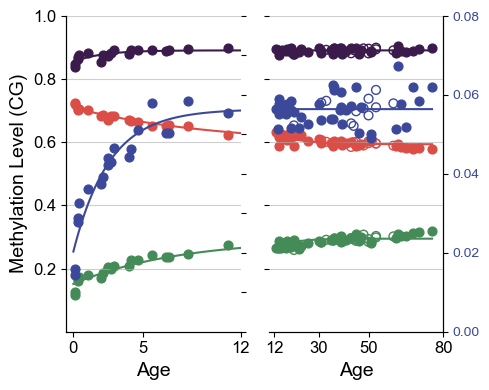

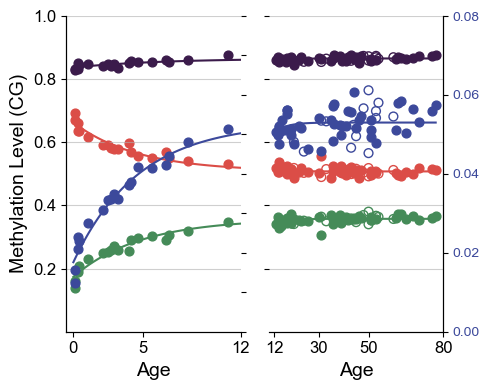

In [11]:
for celltype in ['GABA','GLU']:
    df_reset = df_means.reset_index()  
    df_reset = df_reset[df_reset['celltype'] == celltype]
    df_wide = df_reset.pivot_table(
    index=['age','subject'],
    columns=['mctype','ctxt'],
    values='mean',
    aggfunc='mean'  # or 'median', 'sum', etc.
    )

    df_wide.columns = ['tmCG','tmCH','mCG','mCH']
    df_wide = df_wide[['tmCG','tmCH','mCG']]

    def exp_func(x, a, b, c):
        return a * np.exp(b * x) + c
    # 3. Create the difference column (5hmC = BS - OXBS)
    df_wide['hmCG'] = df_wide['tmCG'] - df_wide['mCG']

    # 4. Plot scatter plots for each column vs. age
    x_data = df_wide.index.get_level_values(0).astype(float)
    SCZ = [metafile[metafile['Sample ID'] == i]['DISORDER'].iloc[0] for i in df_wide.index.get_level_values(1)]

    def exp_func(x, a, b, c):
        return a * np.exp(b * x) + c

    fit_results = {}
    cov_matrices = {}

    for col in ['tmCG', 'mCG', 'hmCG', 'tmCH']:
        y_data = df_wide[col].values.astype(float)

        popt, pcov = curve_fit(exp_func, x_data, y_data, p0=(1.0, -0.1, 1.0))

        fit_results[col] = popt
        cov_matrices[col] = pcov  
    x_fit = np.linspace(x_data.min(), x_data.max(), 200)

    # Define color map
    color_map = {'tmCG': '#3B1B4B', 'mCG': '#db4d47', 'hmCG': '#458B58','tmCH': '#3C499B'}

    x_fit = np.linspace(x_data.min(), x_data.max(), 200)

    # Define x fits for two ranges
    x_fit_1 = np.linspace(0, 12, 100)
    x_fit_2 = np.linspace(12, x_data.max(), 100)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5,4), sharey=True)
    ax1_right = ax1.twinx()
    ax2_right = ax2.twinx()

    for col in ['tmCG', 'mCG', 'hmCG', 'tmCH']:
        y_data = df_wide[col].values.astype(float)
        popt = fit_results[col]

        for x, y, scz_status in zip(x_data, y_data, SCZ):
            if x <= 12:
                ax = ax1 if col != 'tmCH' else ax1_right
            else:
                ax = ax2 if col != 'tmCH' else ax2_right
        
            if scz_status == 'S':
                ax.scatter(x, y, facecolors='none', edgecolors=color_map[col], s=40)
            else:
                ax.scatter(x, y, color=color_map[col], s=40)

        # Plot fits
        y_fit_1 = exp_func(x_fit_1, *popt)
        y_fit_2 = exp_func(x_fit_2, *popt)

        if col != 'tmCH':
            ax1.plot(x_fit_1, y_fit_1, label=f'{col} (fit)', color=color_map[col])
            ax2.plot(x_fit_2, y_fit_2, label=f'{col} (fit)', color=color_map[col])
        else:
            ax1_right.plot(x_fit_1, y_fit_1, label=f'{col} (fit)', color=color_map[col])
            ax2_right.plot(x_fit_2, y_fit_2, label=f'{col} (fit)', color=color_map[col])

    # Format left y-axis
    ax1.set_xlabel('Age', size=14)
    ax1.set_xticks([0, 5, 12])
    ax1.set_xlim([-0.5,12])
    ax1.tick_params(axis='both', labelsize=12)
    ax1.grid(axis='y', linestyle='-', alpha=0.6)

    ax2.set_xlabel('Age', size=14)
    ax2.set_xticks([12,30,50,80])
    ax2.set_xlim([10,80])
    ax2.tick_params(axis='both', labelsize=12)
    ax2.grid(axis='y', linestyle='-', alpha=0.6)

    ax1.set_ylabel('Methylation Level (CG)', size=14)
    ax1.set_ylim([0,1])
    ax2.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])

    # Format right y-axis for tmCH
    ax1_right.set_ylabel('', color=color_map['tmCH'], size=14)
    ax1_right.tick_params(axis='y', labelcolor=color_map['tmCH'])
    ax1_right.set_ylim([0,0.08])
    # ax1_right.tick_params(axis='y', labelleft=False, left=False)
    ax1_right.set_yticklabels([])

    # ax2_right.set_ylabel('Methylation Level (CH)', color=color_map['tmCH'], size=14)
    ax2_right.tick_params(axis='y', labelcolor=color_map['tmCH'])
    ax2_right.set_ylim([0,0.08])
    ax2_right.set_yticks([0,0.02, 0.04, 0.06, 0.08])

    # Remove spines from main axes
    ax1.spines['right'].set_visible(False)
    ax1.spines['top'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    # Remove spines from twin axes
    for spine in ['top', 'right']:
        ax1_right.spines[spine].set_visible(False)
    for spine in ['top', 'left']:
        ax2_right.spines[spine].set_visible(False)

    plt.tight_layout()
    # plt.savefig(f'/cndd/hex002/PsychEncode/Figures/{celltype}_global_methylation_CGCH.pdf')
    plt.show()

In [12]:
for celltype in ['GLU','GABA']:
    print(f'{celltype}:')
    df_reset = df_means.reset_index()  
    df_reset = df_reset[df_reset['celltype'] == celltype]
    df_wide = df_reset.pivot_table(
    index=['age','subject'],
    columns=['mctype','ctxt'],
    values='mean',
    aggfunc='mean'  # or 'median', 'sum', etc.
    )

    df_wide.columns = ['tmCG','tmCH','mCG','mCH']
    df_wide = df_wide[['tmCG','tmCH','mCG']]
    
    df_wide['hmCG'] = df_wide['tmCG'] - df_wide['mCG']

    
    x_data = df_wide.index.get_level_values(0).astype(float)
    SCZ = np.array([
                    metafile.loc[metafile['Sample ID'].eq(i), 'DISORDER'].iloc[0]
                    for i in df_wide.index.get_level_values(1)
                ])

    
    mask = (SCZ != 'S')

    x_fit = np.asarray(x_data, dtype=float)[mask]

    def exp_func_tau(x, a, tau, c):
        return a * np.exp(-x / tau) + c

    fit_results = {}
    cov_matrices = {}

    for col in ['tmCG', 'mCG', 'hmCG', 'tmCH']:
        y_fit = df_wide[col].values.astype(float)[mask]

        # optional: drop NaNs to avoid curve_fit issues
        ok = np.isfinite(x_fit) & np.isfinite(y_fit)
        x_use = x_fit[ok]
        y_use = y_fit[ok]

        popt, pcov = curve_fit(exp_func_tau, x_use, y_use, p0=(1.0, 1.0, 1.0))
        fit_results[col] = popt
        cov_matrices[col] = pcov

        a, tau, c = popt
        var_tau = pcov[1, 1]
        print(f"{col}: tau = {tau:.4g}, Var(tau) = {var_tau:.4g}, SE = {np.sqrt(var_tau):.4g}")
    print('\n')

GLU:
tmCG: tau = 6.089, Var(tau) = 2.249, SE = 1.5
mCG: tau = 4.547, Var(tau) = 0.1801, SE = 0.4244
hmCG: tau = 4.75, Var(tau) = 0.1327, SE = 0.3643
tmCH: tau = 4.673, Var(tau) = 0.192, SE = 0.4382


GABA:
tmCG: tau = 2.021, Var(tau) = 0.273, SE = 0.5225
mCG: tau = 10.12, Var(tau) = 0.6819, SE = 0.8257
hmCG: tau = 7.34, Var(tau) = 0.4126, SE = 0.6424
tmCH: tau = 2.599, Var(tau) = 0.1084, SE = 0.3292


